# DocForge - Preprocessing

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What are we doing here?
Raw data is never model-ready. In this notebook you will:
1. Load and clean the Code2Doc dataset
2. Normalize code and docstrings so models see consistent input
3. Format the data as prompts for two different model types (CodeT5 and Llama)
4. Save everything so it can be used to train the model 

---
###  Sections
1. Install & Config
2. Load Dataset
3. Flatten Array Columns
4. Basic Cleaning
5. Code Normalization
6. Docstring Normalization
7. Length Check After Cleaning
8. Prompt Formatting — CodeT5
9. Prompt Formatting — Llama 3.1 8B
10. Token Length Verification
11. Save to Disk
12. Final Summary

---
## Section 1 — Install & Config

Run the install cell as-is. Then fill in the config cell — use the values you found in your EDA.

In [9]:
!pip install datasets transformers sentencepiece -q

import re
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, DatasetDict

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [10]:
# Column names from EDA
CODE_COL   = "function_code"
DOC_COL    = "documentation"
LANG_COL   = "language"
QUAL_COL   = "quality_score"
CC_COL     = "complexity"
ANN_COL    = "has_type_hints"
REPO_COL   = "repo_name"
STYLE_COL  = "docstring_style"

# Lengths
MIN_CODE_CHARS  = 20
MAX_CODE_CHARS  = 2000
MIN_DOC_CHARS   = 10
MAX_DOC_CHARS   = 1000
MIN_QUALITY     = 6.0

# Tokenizer Limits
CODET5_MAX_INPUT  = 512
CODET5_MAX_TARGET = 128
LLAMA_MAX_SEQ     = 1024

RANDOM_SEED = 42
OUTPUT_DIR  = '/kaggle/working/processed'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Parameters: ")
print(f'  Code col          : {CODE_COL}')
print(f'  Doc col           : {DOC_COL}')
print(f'  CODET5_MAX_INPUT  : {CODET5_MAX_INPUT}')
print(f'  CODET5_MAX_TARGET : {CODET5_MAX_TARGET}')
print(f'  Output dir        : {OUTPUT_DIR}')

Parameters: 
  Code col          : function_code
  Doc col           : documentation
  CODET5_MAX_INPUT  : 512
  CODET5_MAX_TARGET : 128
  Output dir        : /kaggle/working/processed


---
## Section 2 — Load Dataset

**Task:** Load Code2Doc from HuggingFace.

Important: this dataset **already has train/val/test splits** — do NOT split it yourself.
Load each split into its own separate DataFrame.

**Hint:** Wrap your `load_dataset` call in a retry loop — Kaggle connections can drop.

In [11]:
import time
from datasets import load_dataset

def load_with_retry(dataset_name, retries=3, wait=5):
    for attempt in range(1, retries + 1):
        try:
            dataset = load_dataset(dataset_name)

            print(f"Loaded successfully on attempt {attempt}")

            return dataset

        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")

            if attempt < retries:
                time.sleep(wait)

    raise Exception("Failed to load dataset after multiple attempts")

dataset = load_with_retry("kaanrkaraman/code2doc")

train_df = dataset["train"].to_pandas()
val_df = dataset["val"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Loaded successfully on attempt 1
Train shape: (10684, 15)
Validation shape: (1334, 15)
Test shape: (1340, 15)


---
## Section 3 — Flatten Array Columns

**Task:** Same as Worksheet 1 — some columns store lists instead of strings.
Fix this in all three DataFrames (train, val, test).

**Hint:** Write a function `flatten_array_cols(df)` and apply it to each split.

In [12]:
import numpy as np

def flatten_array_cols(df):
    for col in df.columns:
        sample = df[col].dropna().iloc[0]

        if isinstance(sample, (list, np.ndarray)):
            print(f"Flattened column: {col}")

            df[col] = df[col].apply(
                lambda x: ", ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x)
    return df

train_df = flatten_array_cols(train_df)
val_df = flatten_array_cols(val_df)
test_df = flatten_array_cols(test_df)

Flattened column: parameters
Flattened column: parameters
Flattened column: parameters


This repeated output is because it ran on all 3 ie: train test and value df to convert columns containing lisrs/arrays into comma seperated strings

---
## Section 4 — Basic Cleaning

**Task:** Apply the following cleaning steps to all three splits:

1. Drop rows where `function_code` or `documentation` is null
2. Convert both to strings and strip leading/trailing whitespace
3. Drop rows where either is empty after stripping
4. Normalize language labels to lowercase (also handle aliases like `c++` → `cpp`)
5. Filter out rows where `quality_score < MIN_QUALITY` (safety net)
6. Fill null values in the `parameters` column with an empty string

Print how many rows are removed at each step.

In [13]:
print(train_df.columns)

Index(['function_name', 'function_code', 'documentation', 'language',
       'file_path', 'line_number', 'parameters', 'return_type',
       'has_type_hints', 'complexity', 'quality_score', 'repo_name',
       'repo_stars', 'docstring_style', 'is_async'],
      dtype='object')


In [14]:
def basic_clean(df, split_name):
    start_rows = len(df)

    df = df.dropna(subset=[CODE_COL, DOC_COL])
    df[CODE_COL] = df[CODE_COL].astype(str).str.strip()
    df[DOC_COL] = df[DOC_COL].astype(str).str.strip()
    df = df[(df[CODE_COL] != "") & (df[DOC_COL] != "")]
    df[LANG_COL] = df[LANG_COL].str.lower()
    df[LANG_COL] = df[LANG_COL].replace({"c++": "cpp"})
    df = df[df[QUAL_COL] >= MIN_QUALITY]

    if "parameters" in df.columns:
        df["parameters"] = df["parameters"].fillna("")

    end_rows = len(df)
    print(f"{split_name}: {start_rows} → {end_rows} rows (removed {start_rows - end_rows})")
    return df

train_df = basic_clean(train_df, "Train")
val_df = basic_clean(val_df, "Validation")
test_df = basic_clean(test_df, "Test")

Train: 10684 → 10684 rows (removed 0)
Validation: 1334 → 1334 rows (removed 0)
Test: 1340 → 1340 rows (removed 0)


---
## Section 5 — Code Normalization

**Task:** Write a function that normalizes raw source code. Then apply it to all three splits.

Your normalization function should:
- Convert `\r\n` and `\r` line endings to `\n`
- Replace tabs with 4 spaces
- Strip trailing whitespace from each line
- Collapse 3 or more consecutive blank lines down to 2
- Strip leading/trailing whitespace from the whole string

After normalizing, filter out functions that are too short or too long (use `MIN_CODE_CHARS` and `MAX_CODE_CHARS`).

In [15]:
import re

# What to normalize
def normalize_code(code):
    code = code.replace("\r\n", "\n").replace("\r", "\n")
    code = code.replace("\t", "    ")
    code = "\n".join(line.strip() for line in code.split("\n"))
    code = re.sub(r"\n{3,}", "\n\n", code)
    code = code.strip()
    return code

#Applying normalization

def apply_code_normalization(df, split_name):
    before = len(df)

    df["code_clean"] = df[CODE_COL].apply(normalize_code)
    df["code_len"] = df["code_clean"].str.len()

    df = df[
        (df["code_len"] >= MIN_CODE_CHARS) &
        (df["code_len"] <= MAX_CODE_CHARS)]

    after = len(df)
    print(f"{split_name}: removed {before - after} rows after code normalization")
    return df

train_df = apply_code_normalization(train_df, "Train")
val_df = apply_code_normalization(val_df, "Validation")
test_df = apply_code_normalization(test_df, "Test")

print("Original Code:\n")
print(train_df.iloc[0][CODE_COL][:500])
print("\n" + "=" * 70 + "\n")
print("Normalized Code:\n")
print(train_df.iloc[0]["code_clean"][:500])

Train: removed 541 rows after code normalization
Validation: removed 73 rows after code normalization
Test: removed 74 rows after code normalization
Original Code:

function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
        const name = parseIdentifier();
        let constraint: TypeNode | undefined;
        let expression: Expression | undefined;
        if (parseOptional(SyntaxKind.ExtendsKeyword)) {
            // It's not uncommon for people to write improper constraints to a generic.  If the
            /


Normalized Code:

function parseTypeParameter(): TypeParameterDeclaration {
const pos = getNodePos();
const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
const name = parseIdentifier();
let constraint: TypeNode | undefined;
let expression: Expression | undefined;
if (parseOptional(SyntaxKind.Extend

---
## Section 6 — Docstring Normalization

**Task:** Write a function that normalizes raw docstrings. Then apply it to all three splits.

Your normalization function should handle these common patterns:

**Python** docstrings are wrapped in triple quotes:
```
\"\"\"This is the docstring\"\"\"
```
Strip the `\"\"\"` wrappers.

**JavaDoc** comments look like:
```
/**
 * This is the docstring
 * @param x the input
 */
```
Strip the `/**`, `*/`, and leading `* ` from each line.

For all languages:
- Collapse 3+ blank lines to 2
- Replace tabs with single spaces
- Collapse multiple consecutive spaces to one
- Strip leading/trailing whitespace

After normalizing, filter out docstrings outside `[MIN_DOC_CHARS, MAX_DOC_CHARS]`.

In [16]:
import re

def normalize_docstring(doc):
    doc = re.sub(r'^("""|\'\'\')|("""|\'\'\')$', '', doc.strip())
    doc = re.sub(r"^/\*\*", "", doc)
    doc = re.sub(r"\*/$", "", doc)
    doc = "\n".join(line.lstrip("* ").rstrip() for line in doc.split("\n"))
    doc = doc.replace("\t", " ")
    doc = re.sub(r" {2,}", " ", doc)
    doc = re.sub(r"\n{3,}", "\n\n", doc)
    doc = doc.strip()
    return doc

def apply_doc_normalization(df, split_name):
    before = len(df)

    df["doc_clean"] = df[DOC_COL].apply(normalize_docstring)
    df["doc_len"] = df["doc_clean"].str.len()
    df = df[(df["doc_len"] >= MIN_DOC_CHARS) & (df["doc_len"] <= MAX_DOC_CHARS)]
    after = len(df)

    print(f"{split_name}: removed {before - after} rows after doc normalization")
    return df

train_df = apply_doc_normalization(train_df, "Train")
val_df = apply_doc_normalization(val_df, "Validation")
test_df = apply_doc_normalization(test_df, "Test")

java_example = train_df[train_df[LANG_COL] == "java"].iloc[0]

print("Raw Documentation:\n")
print(java_example[DOC_COL][:500])
print("\n" + "=" * 70 + "\n")
print("Cleaned Documentation:\n")
print(java_example["doc_clean"][:500])

Train: removed 569 rows after doc normalization
Validation: removed 78 rows after doc normalization
Test: removed 68 rows after doc normalization
Raw Documentation:

Return the column of the text resource where the property originated.
@return the column number (zero indexed)


Cleaned Documentation:

Return the column of the text resource where the property originated.
@return the column number (zero indexed)


---
## Section 7 — Length Check After Cleaning

**Task:** Confirm the cleaning worked correctly by plotting the length distributions and printing final split sizes.

Also check the language distribution is still balanced across splits.

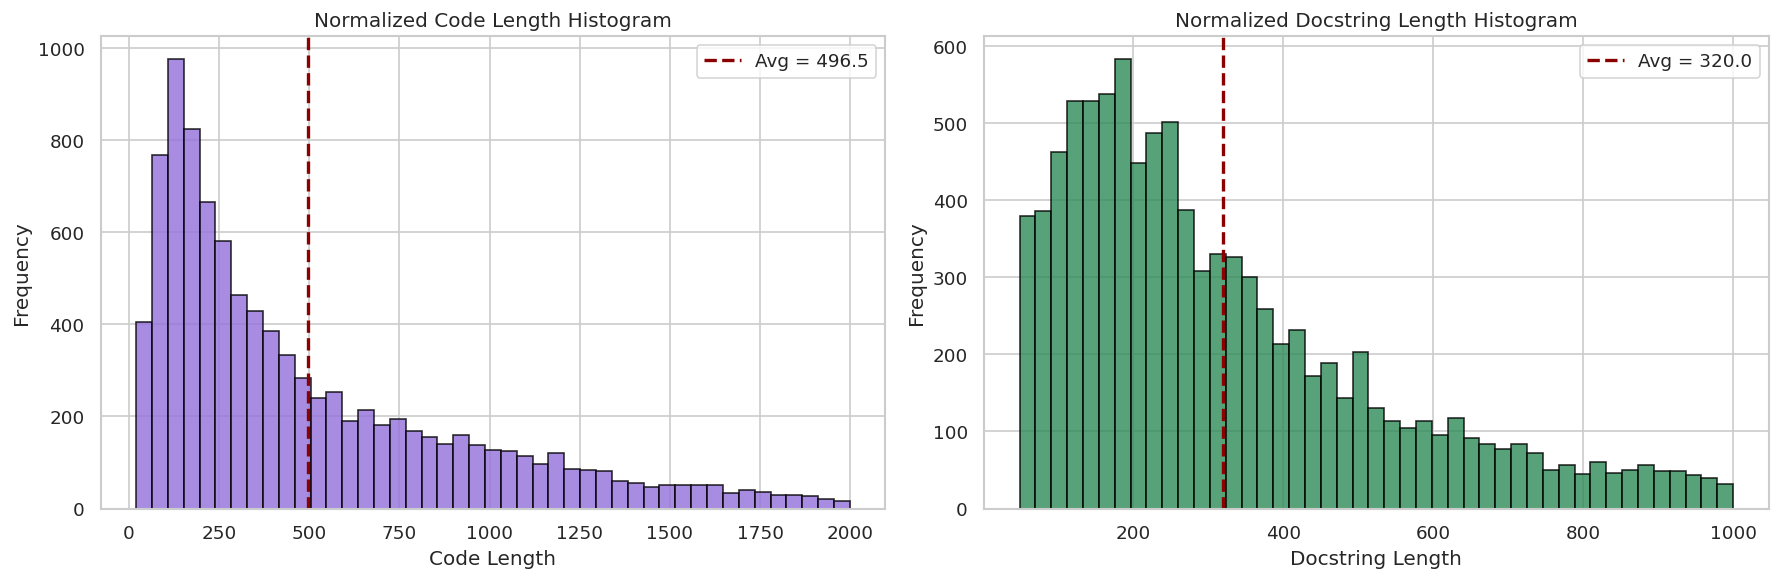

Final train samples      : 9574
Final validation samples : 1183
Final test samples       : 1198

Train Split Language %:

language
java          65.07
python        22.67
typescript     6.67
javascript     4.27
cpp            1.32
Name: proportion, dtype: float64

Validation Split Language %:

language
java          65.51
python        22.06
typescript     6.85
javascript     4.23
cpp            1.35
Name: proportion, dtype: float64

Test Split Language %:

language
java          64.77
python        23.29
typescript     6.34
javascript     4.26
cpp            1.34
Name: proportion, dtype: float64


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(train_df["code_len"], bins=45, color="mediumpurple", edgecolor="black", alpha=0.8)
ax[0].axvline(train_df["code_len"].mean(), color="darkred", linestyle="--", linewidth=2, label=f"Avg = {train_df['code_len'].mean():.1f}")
ax[0].set_title("Normalized Code Length Histogram")
ax[0].set_xlabel("Code Length")
ax[0].set_ylabel("Frequency")
ax[0].legend()

ax[1].hist(train_df["doc_len"], bins=45, color="seagreen", edgecolor="black", alpha=0.8)
ax[1].axvline(train_df["doc_len"].mean(), color="darkred", linestyle="--", linewidth=2, label=f"Avg = {train_df['doc_len'].mean():.1f}")
ax[1].set_title("Normalized Docstring Length Histogram")
ax[1].set_xlabel("Docstring Length")
ax[1].set_ylabel("Frequency")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Final train samples      : {len(train_df)}")
print(f"Final validation samples : {len(val_df)}")
print(f"Final test samples       : {len(test_df)}")

print("\nTrain Split Language %:\n")
print((train_df[LANG_COL].value_counts(normalize=True) * 100).round(2))

print("\nValidation Split Language %:\n")
print((val_df[LANG_COL].value_counts(normalize=True) * 100).round(2))

print("\nTest Split Language %:\n")
print((test_df[LANG_COL].value_counts(normalize=True) * 100).round(2))

---
## Section 8 — Prompt Formatting: CodeT5

**Task:** Format the data for CodeT5, which is a seq2seq (encoder-decoder) model.

CodeT5 takes a plain text **input** and generates a plain text **output**.

Format:
- **Input:** `Summarize {language}: {code_clean}`
- **Target:** `{doc_clean}` (just the cleaned docstring, nothing else)

The `Summarize {language}:` prefix tells the model what language it's looking at and what task to do.

In [18]:
def make_codet5_input(row):
    lang = row[LANG_COL]
    snippet = row["code_clean"]
    return f"Summarize {lang}: {snippet}"

for data in [train_df, val_df, test_df]:
    data["codet5_input"] = data.apply(make_codet5_input, axis=1)
    data["codet5_target"] = data["doc_clean"]

sample_row = train_df.iloc[0]

print("MODEL INPUT:\n")
print(sample_row["codet5_input"][:300])
print("\n" + "=" * 70 + "\n")
print("TARGET DOCSTRING:\n")
print(sample_row["codet5_target"][:300])

MODEL INPUT:

Summarize typescript: function parseTypeParameter(): TypeParameterDeclaration {
const pos = getNodePos();
const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
const name = parseIdentifier();
let constraint: TypeNode | undefined;
let expression: Expression | un


TARGET DOCSTRING:

Reports a diagnostic error for the current token being an invalid name.

@param blankDiagnostic Diagnostic to report for the case of the name being blank (matched tokenIfBlankName).
@param nameDiagnostic Diagnostic to report for all other cases.
@param tokenIfBlankName Current token if the name was 


---
## Section 9 — Prompt Formatting: Llama 3.1 8B

**Task:** Format the data for Llama, which is an instruction-tuned causal language model.

Llama uses a **chat template** with system, user, and assistant turns. The format is:

```
<|begin_of_text|>
<|start_header_id|>system<|end_header_id|>

{system_prompt}<|eot_id|>
<|start_header_id|>user<|end_header_id|>

{user_message}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>

{docstring}<|eot_id|>
```

- The system prompt tells Llama its role (documentation writer)
- The user message contains the function code
- The assistant turn contains the docstring (what the model learns to generate)
- For **inference**, we stop before the assistant's answer so the model fills it in

You need two versions: one WITH the docstring (for training) and one WITHOUT (for inference/evaluation).

In [19]:
SYSTEM_PROMPT = (
    "You are a documentation writer. "
    "When  you are given a function, generate an appropriate description."
    "Generate complete docstring with description, params, and return values.")

def make_llama_prompt(row, include_response=True):
    user_text = f"{row[LANG_COL]} function:\n\n{row['code_clean']}"

    prompt = (
        "<|begin_of_text|>\n"
        "<|start_header_id|>system<|end_header_id|>\n\n"
        f"{SYSTEM_PROMPT}<|eot_id|>\n"
        "<|start_header_id|>user<|end_header_id|>\n\n"
        f"{user_text}<|eot_id|>\n"
        "<|start_header_id|>assistant<|end_header_id|>\n\n")

    if include_response:
        prompt += f"{row['doc_clean']}<|eot_id|>"

    return prompt

for frame in [train_df, val_df, test_df]:
    frame["llama_prompt_train"] = frame.apply(
        lambda row: make_llama_prompt(row, include_response=True),
        axis=1)

    frame["llama_prompt_infer"] = frame.apply(
        lambda row: make_llama_prompt(row, include_response=False),
        axis=1)

print(train_df.iloc[0]["llama_prompt_train"][:600])

<|begin_of_text|>
<|start_header_id|>system<|end_header_id|>

You are a documentation writer. When  you are given a function, generate an appropriate description.Generate complete docstring with description, params, and return values.<|eot_id|>
<|start_header_id|>user<|end_header_id|>

typescript function:

function parseTypeParameter(): TypeParameterDeclaration {
const pos = getNodePos();
const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
const name = parseIdentifier();
let constraint: TypeNode | undefined;
let expression: Expression | undefined;
if (


---
## Section 10 — Token Length Verification

**Task:** Verify that your chosen `max_input_length` and `max_target_length` values are appropriate.

Use the chars ÷ 4 approximation (same as EDA — avoids the tokenizer version conflict).

Check coverage for CodeT5 inputs, CodeT5 targets, and full Llama sequences.

In [20]:
sample_df = train_df.sample(2000, random_state=42).copy()
sample_df["codet5_input_tokens"] = sample_df["codet5_input"].str.len() // 4
sample_df["codet5_target_tokens"] = sample_df["codet5_target"].str.len() // 4
sample_df["llama_full_tokens"] = sample_df["llama_prompt_train"].str.len() // 4

print("CodeT5 Input Coverage:\n")

for limit in [256, 512, 1024]:
    pct = (sample_df["codet5_input_tokens"] <= limit).mean() * 100

    print(f"<= {limit} tokens : {pct:.2f}%")

print("\nCodeT5 Target Coverage:\n")

for limit in [128, 256, 512]:
    pct = (sample_df["codet5_target_tokens"] <= limit).mean() * 100

    print(f"<= {limit} tokens : {pct:.2f}%")

print("\nLlama Full Prompt Coverage:\n")

for limit in [512, 1024, 2048]:
    pct = (sample_df["llama_full_tokens"] <= limit).mean() * 100

    print(f"<= {limit} tokens : {pct:.2f}%")

input_cov = (sample_df["codet5_input_tokens"] <= CODET5_MAX_INPUT).mean() * 100

print(f"\n The Current CODET5_MAX_INPUT ({CODET5_MAX_INPUT}) covers {input_cov:.2f}% of samples")

CodeT5 Input Coverage:

<= 256 tokens : 85.70%
<= 512 tokens : 100.00%
<= 1024 tokens : 100.00%

CodeT5 Target Coverage:

<= 128 tokens : 83.85%
<= 256 tokens : 100.00%
<= 512 tokens : 100.00%

Llama Full Prompt Coverage:

<= 512 tokens : 91.55%
<= 1024 tokens : 100.00%
<= 2048 tokens : 100.00%

Current CODET5_MAX_INPUT (512) covers 100.00% of samples


---
## Section 11 — Save to Disk

**Task:** Save the processed datasets in three formats:

1. **CSV** — easy to inspect and debug (save train, val, test)
2. **JSONL** — one JSON object per line, preferred format for Llama fine-tuning
3. **HuggingFace DatasetDict** — native format for training with the `transformers` library

Save two DatasetDicts: one with CodeT5 columns, one with Llama columns.

Also save a `preprocessing_config.json` so future notebooks know exactly what settings were used.

In [21]:
import json
from datasets import Dataset, DatasetDict

meta_cols = ["function_name", "language", "quality_score", "complexity", "repo_name", "docstring_style", "parameters", "return_type"]

META_COLS = [col for col in meta_cols if col in train_df.columns]

CODET5_COLS = META_COLS + ["code_clean", "doc_clean", "codet5_input", "codet5_target"]
LLAMA_COLS = META_COLS + ["code_clean", "doc_clean", "llama_prompt_train", "llama_prompt_infer"]

all_cols = list(dict.fromkeys(CODET5_COLS + LLAMA_COLS))

train_df[all_cols].to_csv(f"{OUTPUT_DIR}/train.csv", index=False)
val_df[all_cols].to_csv(f"{OUTPUT_DIR}/val.csv", index=False)
test_df[all_cols].to_csv(f"{OUTPUT_DIR}/test.csv", index=False)

train_df[LLAMA_COLS].to_json(f"{OUTPUT_DIR}/train_llama.jsonl", orient="records", lines=True)
val_df[LLAMA_COLS].to_json(f"{OUTPUT_DIR}/val_llama.jsonl", orient="records", lines=True)
test_df[LLAMA_COLS].to_json(f"{OUTPUT_DIR}/test_llama.jsonl", orient="records", lines=True)

codet5_dataset = DatasetDict({"train": Dataset.from_pandas(train_df[CODET5_COLS]), "validation": Dataset.from_pandas(val_df[CODET5_COLS]), "test": Dataset.from_pandas(test_df[CODET5_COLS])})
codet5_dataset.save_to_disk(f"{OUTPUT_DIR}/codet5_dataset")
llama_dataset = DatasetDict({"train": Dataset.from_pandas(train_df[LLAMA_COLS]), "validation": Dataset.from_pandas(val_df[LLAMA_COLS]), "test": Dataset.from_pandas(test_df[LLAMA_COLS])})
llama_dataset.save_to_disk(f"{OUTPUT_DIR}/llama_dataset")

#Wrinting the config_data dictionary

config_data = {
    "code_column": CODE_COL,
    "doc_column": DOC_COL,
    "language_column": LANG_COL,
    "quality_column": QUAL_COL,
    "complexity_column": CC_COL,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
    "train_language_distribution": train_df[LANG_COL].value_counts(normalize=True).round(4).to_dict(),
    "min_code_chars": MIN_CODE_CHARS,
    "max_code_chars": MAX_CODE_CHARS,
    "min_doc_chars": MIN_DOC_CHARS,
    "max_doc_chars": MAX_DOC_CHARS,
    "min_quality": MIN_QUALITY,
    "codet5_max_input": CODET5_MAX_INPUT,
    "codet5_max_target": CODET5_MAX_TARGET,
    "llama_max_seq": LLAMA_MAX_SEQ
}

with open(f"{OUTPUT_DIR}/preprocessing_config.json", "w") as f:
    json.dump(config_data, f, indent=4)

print(f"Saved: {OUTPUT_DIR}/train.csv")
print(f"Saved: {OUTPUT_DIR}/val.csv")
print(f"Saved: {OUTPUT_DIR}/test.csv")
print(f"Saved: {OUTPUT_DIR}/train_llama.jsonl")
print(f"Saved: {OUTPUT_DIR}/val_llama.jsonl")
print(f"Saved: {OUTPUT_DIR}/test_llama.jsonl")
print(f"Saved: {OUTPUT_DIR}/codet5_dataset")
print(f"Saved: {OUTPUT_DIR}/llama_dataset")
print(f"Saved: {OUTPUT_DIR}/preprocessing_config.json")

Saving the dataset (0/1 shards):   0%|          | 0/9574 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1183 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1198 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/9574 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1183 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1198 [00:00<?, ? examples/s]

Saved: /kaggle/working/processed/train.csv
Saved: /kaggle/working/processed/val.csv
Saved: /kaggle/working/processed/test.csv
Saved: /kaggle/working/processed/train_llama.jsonl
Saved: /kaggle/working/processed/val_llama.jsonl
Saved: /kaggle/working/processed/test_llama.jsonl
Saved: /kaggle/working/processed/codet5_dataset
Saved: /kaggle/working/processed/llama_dataset
Saved: /kaggle/working/processed/preprocessing_config.json


---
## Section 12 — Final Summary

**Task:** Fill in the summary below. Replace every `???` with the real value.

This summary will be your reference card when writing Notebooks 3a, 3b, and 3c.

In [22]:
print("=" * 65)
print("        DOCFORGE — PREPROCESSING SUMMARY")
print("=" * 65)

print(f"""
Cleaning Steps Applied
  1. Flattened array columns        : yes
  2. Dropped null rows              : yes
  3. Normalized language labels     : yes
  4. Quality filter (>= {MIN_QUALITY})        : yes
  5. Code normalization             : yes
  6. Code length filter [{MIN_CODE_CHARS}, {MAX_CODE_CHARS}]  : yes
  7. Docstring normalization        : yes
  8. Doc length filter  [{MIN_DOC_CHARS}, {MAX_DOC_CHARS}]  : yes

Final Dataset Sizes
  Train : {len(train_df)}
  Val   : {len(val_df)}
  Test  : {len(test_df)}

Files Saved
  CSV files        : train.csv, val.csv, test.csv
  JSONL files      : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
  HF DatasetDicts  : codet5_dataset/, llama_dataset/
  Config           : preprocessing_config.json

Notebook 3 Quick Reference
  CodeT5 input column   : 'codet5_input'
  CodeT5 target column  : 'codet5_target'
  CodeT5 max_input      : {CODET5_MAX_INPUT}
  CodeT5 max_target     : {CODET5_MAX_TARGET}

  Llama train column    : 'llama_prompt_train'
  Llama infer column    : 'llama_prompt_infer'
  Llama max_seq         : {LLAMA_MAX_SEQ}
""")

print("=" * 65)

        DOCFORGE — PREPROCESSING SUMMARY

Cleaning Steps Applied
  1. Flattened array columns        : yes
  2. Dropped null rows              : yes
  3. Normalized language labels     : yes
  4. Quality filter (>= 6.0)        : yes
  5. Code normalization             : yes
  6. Code length filter [20, 2000]  : yes
  7. Docstring normalization        : yes
  8. Doc length filter  [10, 1000]  : yes

Final Dataset Sizes
  Train : 9574
  Val   : 1183
  Test  : 1198

Files Saved
  CSV files        : train.csv, val.csv, test.csv
  JSONL files      : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
  HF DatasetDicts  : codet5_dataset/, llama_dataset/
  Config           : preprocessing_config.json

Notebook 3 Quick Reference
  CodeT5 input column   : 'codet5_input'
  CodeT5 target column  : 'codet5_target'
  CodeT5 max_input      : 512
  CodeT5 max_target     : 128

  Llama train column    : 'llama_prompt_train'
  Llama infer column    : 'llama_prompt_infer'
  Llama max_seq         : 1024

---
##  Done!

Before going ahead, make sure you can answer these questions:

1. Why do we normalize code before feeding it to the model?
2. What is the difference between `codet5_input` and `llama_prompt_train`?
3. Why do we need two Llama prompt versions (`_train` and `_infer`)?
4. Why do we save in JSONL format for Llama but HuggingFace DatasetDict for CodeT5?
5. Why didn't we re-split the dataset into train/val/test ourselves?
6. What would happen if we skipped the docstring normalization step for Java code?

Write your answers in the cell below as comments.

In [23]:
# Q1: Why normalize code?
# Answer: Often, the code is too large and contains unnecessary information that can be avoided. Our DocStrings already have to go through
# hundreds of words and lines to give an output. Normalizing helps in making this task easier and more efficient as it removes unnecessary spaces, dashes
# to reduce training time, and makes the entire implementation process easier.

# Q2: Difference between codet5_input and llama_prompt_train
# Answer: codet5__input uses simple seq2seq input with an encoder-decoder transformer architecture.  Whereas llamas, on the other hand, have system, user 
#, and assistant sections that give chat prompts.

# Q3: Why two Llama prompt versions?
# Answer: We are using 2 prompt versions: llama_prompt_train and llama_prompt_infer. 
# llama_prompt_train displays the response that the model gives after training to give accurate outputs. 
# llama_prompt_infer works until the response is generated so that llama can infer the code and then generate docstrings.

# Q4: JSONL vs HuggingFace DatasetDict
# Answer: JSONL is used for fine-tuning pipelines. HuggingFace DatasetDict supports tokenization, loading data, and positional encoding while inputting
# data. It is basically the dataset used for the transformer architecture.

# Q5: Why not re-split?
# Answer: Re-splitting means creating new train/validation/test splits yourself instead of using the EDA’s existing splits. This would create 
# discrepancies and inaccurate evaluation. In the same dataset, having 2 splits would create confusion for the model as to where exactly to extract data
# from. Thus, re-splitting is not advisable here.

# Q6: What happens if we skip docstring normalization for Java?
# Answer: Java is a programming language that has complex syntax that can confuse the model during the training process. Java docstrings have symbols 
# like */, /** etc that need to be normalized so that the model can focus on more relevant info. This will improve efficiency and reduce training time.
